# EDA — Análisis Exploratorio de Datos

## ¿Qué es el EDA y por qué importa?

**EDA** (Exploratory Data Analysis) es el proceso de investigar un dataset *antes* de
construir modelos o tomar decisiones. Piénsalo como conocer a alguien antes de pedirle algo importante:
quieres saber quién es, qué puede hacer, y cuáles son sus limitaciones.

Sin EDA puedes:
- Entrenar un modelo con datos erróneos y obtener resultados sin sentido
- Llegar a conclusiones incorrectas por ignorar valores atípicos
- Perder horas depurando un modelo cuando el problema era en los datos

## Flujo de trabajo del EDA

```
1. Cargar y hacer primera inspección
      ↓
2. Calidad de datos (nulos, duplicados, errores)
      ↓
3. Análisis univariado (variable por variable)
      ↓
4. Análisis bivariado (relación entre pares de variables)
      ↓
5. Análisis multivariado (varias variables a la vez)
      ↓
6. Ingeniería de features y limpieza final
      ↓
7. Conclusiones e hipótesis para el modelado
```

## Dataset de este notebook

Trabajaremos con un dataset sintético de **estudiantes universitarios** que incluye:
- Información demográfica: carrera, ciudad, semestre, edad
- Información académica: notas en 3 materias
- Información socioeconómica: horas de estudio, ingreso familiar

**Intencionalidad pedagógica:** el dataset tiene errores comunes que encontrarás en datos reales:
valores faltantes, duplicados y valores fuera de rango.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


---
## 1. Generación del Dataset

En proyectos reales los datos vienen de CSV, bases de datos o APIs. Aquí los generamos
con `numpy` para tener un dataset controlado con características conocidas.

Nota cómo introducimos intencionalmente:
- **Valores nulos** (~6% en las notas, ~3% en ciudad)
- **Duplicados** (3 filas repetidas al final)
- **Correlaciones** entre variables (nota depende de horas de estudio)

In [2]:
rng = np.random.default_rng(2024)
N   = 300

carreras = ['Ingeniería', 'Ciencias', 'Matemáticas', 'Física', 'Química']
ciudades = ['Guatemala', 'Quetzaltenango', 'Cobán', 'Antigua', 'Escuintla']

carrera_arr = rng.choice(carreras, N, p=[0.35, 0.20, 0.20, 0.15, 0.10])
ciudad_arr  = rng.choice(ciudades, N, p=[0.50, 0.20, 0.10, 0.12, 0.08])
semestre    = rng.integers(1, 9, N)
edad        = (18 + semestre * 0.6 + rng.normal(0, 1, N)).astype(int).clip(17, 30)
horas_est   = rng.uniform(2, 12, N).round(1)
ingreso_fam = rng.exponential(scale=5000, size=N).clip(1500, 25000).round(0)

# Notas: dependen de horas de estudio e ingreso familiar (correlación real)
nota_base = 50 + 3.5 * horas_est + ingreso_fam / 2000 + rng.normal(0, 8, N)
nota_mat  = nota_base.clip(30, 100).round(1)
nota_fis  = (nota_base - 5 + rng.normal(0, 6, N)).clip(30, 100).round(1)
nota_prog = (nota_base + 3 + rng.normal(0, 5, N)).clip(30, 100).round(1)

# Introducir ~6% de valores nulos en notas
for arr in [nota_mat, nota_fis, nota_prog]:
    idx_nan = rng.choice(N, size=int(N * 0.06), replace=False)
    arr[idx_nan] = np.nan

# Introducir ~3% de nulos en ciudad
ciudad_arr = ciudad_arr.astype(object)
ciudad_arr[rng.choice(N, size=10, replace=False)] = None

df = pd.DataFrame({
    'id':        range(1, N + 1),
    'carrera':   carrera_arr,
    'ciudad':    ciudad_arr,
    'semestre':  semestre,
    'edad':      edad,
    'horas_est': horas_est,
    'ingreso':   ingreso_fam,
    'nota_mat':  nota_mat,
    'nota_fis':  nota_fis,
    'nota_prog': nota_prog,
})

# Agregar 3 filas duplicadas al final
df = pd.concat([df, df.iloc[[5, 42, 99]]], ignore_index=True)

print(f'Dataset generado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(5)

Dataset generado: 303 filas × 10 columnas


,id,carrera,ciudad,semestre,edad,horas_est,ingreso,nota_mat,nota_fis,nota_prog
0,1,Matemáticas,Quetzaltenango,1,18,8.6,1500.0,75.6,72.7,78.5
1,2,Ingeniería,Antigua,6,20,3.5,1500.0,54.4,43.6,56.0
2,3,Ingeniería,Antigua,1,17,4.5,4853.0,74.9,83.0,NaN
3,4,Física,Guatemala,2,20,2.3,14154.0,66.7,69.8,75.9
4,5,Química,Antigua,1,19,12.0,1500.0,98.9,NaN,100.0


---
## 2. Primera Inspección

Antes de hacer cualquier análisis, necesitas **conocer la estructura** de tu dataset.
Estas son las preguntas básicas:

| Pregunta | Función |
|---|---|
| ¿Cuántas filas y columnas? | `df.shape` |
| ¿Qué tipo de dato tiene cada columna? | `df.dtypes` |
| ¿Cómo se ven los primeros registros? | `df.head()` |
| ¿Hay valores nulos? | `df.isnull().sum()` |
| ¿Cuál es el rango de cada variable numérica? | `df.describe()` |

Un truco útil: `df.info()` te da shape, tipos y conteo de no-nulos todo en una sola llamada.

In [3]:
print('=== Shape del dataset ===')
print(f'Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}')

print('\n=== Información general (tipos + nulos) ===')
df.info()

print('\n=== Primeras 3 filas ===')
print(df.head(3).to_string())

=== Shape del dataset ===
Filas: 303  |  Columnas: 10

=== Información general (tipos + nulos) ===
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         303 non-null    int64  
 1   carrera    303 non-null    str    
 2   ciudad     293 non-null    str    
 3   semestre   303 non-null    int64  
 4   edad       303 non-null    int64  
 5   horas_est  303 non-null    float64
 6   ingreso    303 non-null    float64
 7   nota_mat   285 non-null    float64
 8   nota_fis   285 non-null    float64
 9   nota_prog  284 non-null    float64
dtypes: float64(5), int64(3), str(2)
memory usage: 23.8 KB

=== Primeras 3 filas ===
   id      carrera          ciudad  semestre  edad  horas_est  ingreso  nota_mat  nota_fis  nota_prog
0   1  Matemáticas  Quetzaltenango         1    18        8.6   1500.0      75.6      72.7       78.5
1   2   Ingeniería         Antigua    

In [4]:
# describe() genera estadísticos de resumen para todas las columnas numéricas
# include='all' también incluye las columnas de texto (object)
print('=== Estadísticos descriptivos ===')
df.describe(include='all').round(2)

=== Estadísticos descriptivos ===


,id,carrera,ciudad,semestre,edad,horas_est,ingreso,nota_mat,nota_fis,nota_prog
count,303.00,303,293,303.00,303.00,303.00,303.00,285.00,285.00,284.00
unique,NaN,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ingeniería,Guatemala,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,123,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,149.50,NaN,NaN,4.58,20.28,7.23,5716.61,77.11,72.18,80.29
std,86.98,NaN,NaN,2.30,1.74,2.91,5323.13,12.83,14.67,13.12
min,1.00,NaN,NaN,1.00,17.00,2.00,1500.00,44.20,30.00,48.30
25%,74.50,NaN,NaN,3.00,19.00,4.70,1691.00,67.50,62.70,70.68
50%,149.00,NaN,NaN,5.00,20.00,7.40,3741.00,78.00,72.50,80.30
75%,224.50,NaN,NaN,7.00,22.00,9.70,7361.00,85.60,82.40,92.18


---
## 3. Calidad de Datos

Esta es la etapa más importante: **los datos limpios son la base de cualquier análisis correcto**.

Revisamos 3 problemas típicos:
1. Valores nulos (NaN)
2. Filas duplicadas
3. Valores fuera de rango

### 3.1 Valores Nulos

Un valor nulo indica que la observación está incompleta. Puede ocurrir porque:
- El dato nunca fue registrado
- Hubo un error en la captura
- La pregunta no aplicaba para esa persona

**¿Qué hacer con los nulos?** Depende del porcentaje y del contexto:
- **< 5%**: Generalmente se pueden imputar (rellenar) con media, mediana o moda
- **5–30%**: Requiere cuidado — imputar puede introducir sesgo
- **> 30%**: Considerar eliminar la columna o técnicas avanzadas de imputación

Columnas con valores faltantes:
           nulos  porcentaje     tipo
ciudad        10        3.30      str
nota_mat      18        5.94  float64
nota_fis      18        5.94  float64
nota_prog     19        6.27  float64


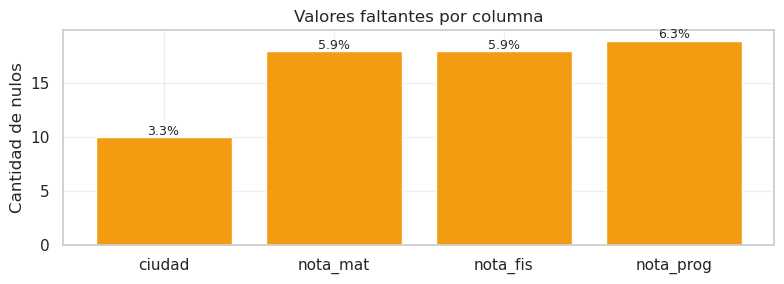

In [5]:
# Calcular nulos y porcentaje por columna
nulos   = df.isnull().sum()
pct_nan = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'nulos':      nulos,
    'porcentaje': pct_nan,
    'tipo':       df.dtypes
})

# Mostrar solo columnas con al menos 1 nulo
print('Columnas con valores faltantes:')
print(resumen_nulos[resumen_nulos['nulos'] > 0])

# ── Visualización ──
cols_con_nulos = nulos[nulos > 0]
fig, ax = plt.subplots(figsize=(8, 3))

# Ciclo for: color condicional según gravedad
colores_nan = []
for col, cantidad in cols_con_nulos.items():
    porcentaje = cantidad / len(df) * 100
    if porcentaje > 10:
        colores_nan.append('#e74c3c')    # rojo: grave
    else:
        colores_nan.append('#f39c12')    # naranja: moderado

bars = ax.bar(cols_con_nulos.index, cols_con_nulos.values, color=colores_nan)

for bar, (col, cant) in zip(bars, cols_con_nulos.items()):
    pct = cant / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'{pct:.1f}%',
            ha='center', fontsize=9)

ax.set_title('Valores faltantes por columna')
ax.set_ylabel('Cantidad de nulos')
plt.tight_layout()
plt.show()

### 3.2 Filas Duplicadas

Una fila duplicada es una observación repetida. Si no la eliminas, estás contando
esos registros doble, lo que sesgará todos tus promedios y conteos.

In [6]:
n_dup = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {n_dup}')

if n_dup > 0:
    print('\nDetalle de los duplicados (keep=False muestra todas las copias):')
    print(df[df.duplicated(keep=False)].sort_values('id')[['id', 'carrera', 'semestre', 'nota_mat']])

# Eliminar duplicados y reiniciar el índice
df = df.drop_duplicates().reset_index(drop=True)
print(f'\nShape después de eliminar duplicados: {df.shape}')

Filas duplicadas encontradas: 3

Detalle de los duplicados (keep=False muestra todas las copias):
      id      carrera  semestre  nota_mat
5      6   Ingeniería         7      71.8
300    6   Ingeniería         7      71.8
42    43      Química         2      84.2
301   43      Química         2      84.2
99   100  Matemáticas         6      65.7
302  100  Matemáticas         6      65.7

Shape después de eliminar duplicados: (300, 10)


### 3.3 Valores Fuera de Rango

Un valor técnicamente no nulo puede ser **imposible** o **improbable**.
Por ejemplo: una nota de 150, una edad negativa, o una semana de 9 días.

Usamos un ciclo `for` para verificar el rango esperado de cada variable.

In [7]:
# Definimos los rangos válidos para cada variable
rangos_validos = {
    'semestre':  (1, 8),
    'edad':      (17, 35),
    'horas_est': (0, 16),
    'ingreso':   (0, 50000),
    'nota_mat':  (0, 100),
    'nota_fis':  (0, 100),
    'nota_prog': (0, 100),
}

print('Verificación de rangos:')
print(f'{"Variable":<15} {"Mín datos":>10} {"Máx datos":>10} {"Rango esperado":<20} {"Estado"}')
print('-' * 65)

for col, (min_esp, max_esp) in rangos_validos.items():
    datos_col = df[col].dropna()
    min_real  = datos_col.min()
    max_real  = datos_col.max()

    # Condicional: verificar si el rango real está dentro del esperado
    if min_real >= min_esp and max_real <= max_esp:
        estado = '✓ OK'
    else:
        estado = '✗ FUERA DE RANGO'

    print(f'{col:<15} {min_real:>10.1f} {max_real:>10.1f} '
          f'[{min_esp}, {max_esp}]{"":>10} {estado}')

Verificación de rangos:
Variable         Mín datos  Máx datos Rango esperado       Estado
-----------------------------------------------------------------
semestre               1.0        8.0 [1, 8]           ✓ OK
edad                  17.0       24.0 [17, 35]           ✓ OK
horas_est              2.0       12.0 [0, 16]           ✓ OK
ingreso             1500.0    25000.0 [0, 50000]           ✓ OK
nota_mat              44.2      100.0 [0, 100]           ✓ OK
nota_fis              30.0      100.0 [0, 100]           ✓ OK
nota_prog             48.3      100.0 [0, 100]           ✓ OK


---
## 4. Análisis Univariado

El análisis univariado examina **cada variable individualmente**.
El objetivo es entender su distribución: ¿dónde se concentran los valores?
¿Tiene una forma de campana? ¿Está sesgada?

### 4.1 Variables Categóricas — Frecuencias

Para variables categóricas (carrera, ciudad), la pregunta clave es:
**¿Cuántos registros hay en cada categoría?**
Si hay un desbalance muy grande, puede afectar los análisis por grupo.

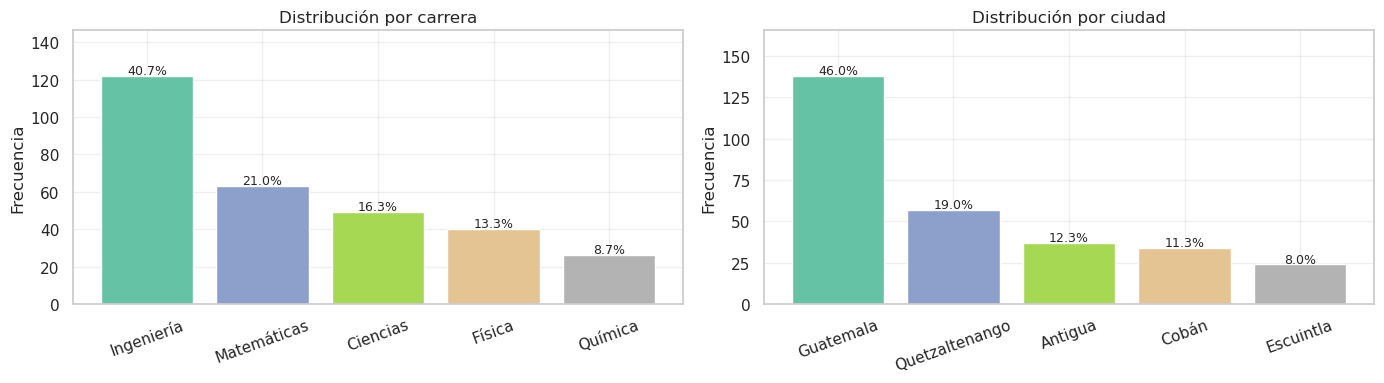


Frecuencia de carrera:
carrera
Ingeniería     122
Matemáticas     63
Ciencias        49
Física          40
Química         26
Name: count, dtype: int64

Frecuencia de ciudad:
ciudad
Guatemala         138
Quetzaltenango     57
Antigua            37
Cobán              34
Escuintla          24
NaN                10
Name: count, dtype: int64


In [8]:
variables_categoricas = ['carrera', 'ciudad']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# === Ciclo for: un subplot por variable categórica ===
for i, col in enumerate(variables_categoricas):
    conteo = df[col].value_counts().dropna()
    pct    = (conteo / len(df) * 100).round(1)

    colores = plt.cm.Set2(np.linspace(0, 1, len(conteo)))
    bars = axes[i].bar(conteo.index, conteo.values, color=colores)

    # Agregar porcentaje sobre cada barra
    for bar, p in zip(bars, pct.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 1,
                     f'{p}%',
                     ha='center', fontsize=9)

    axes[i].set_title(f'Distribución por {col}')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].set_ylim(0, conteo.max() * 1.2)

plt.tight_layout()
plt.show()

# Imprimir las tablas de frecuencia
for col in variables_categoricas:
    print(f'\nFrecuencia de {col}:')
    print(df[col].value_counts(dropna=False))

### 4.2 Variables Numéricas — Distribuciones

Para variables numéricas usamos histogramas y estadísticos de resumen.
Las preguntas clave son:
- **¿Dónde está el centro?** (media, mediana)
- **¿Cuánto varían los datos?** (desviación estándar, rango intercuartílico)
- **¿La distribución es simétrica?** (si media ≈ mediana → sí; si no → hay sesgo)

Usamos un ciclo `for` para generar todos los histogramas automáticamente.

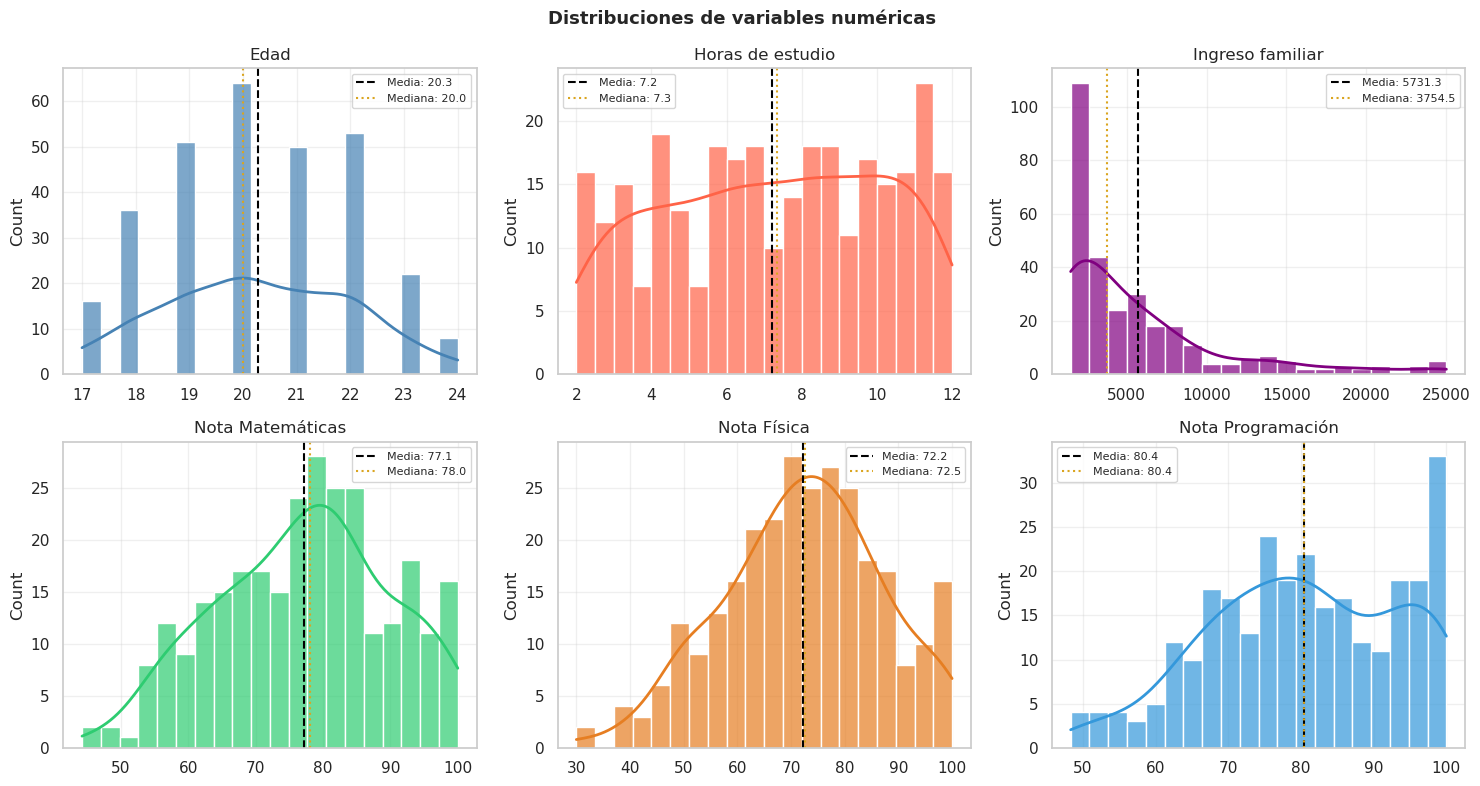

In [9]:
cols_numericas = [
    ('edad',      'Edad',              'steelblue'),
    ('horas_est', 'Horas de estudio',  'tomato'),
    ('ingreso',   'Ingreso familiar',  'purple'),
    ('nota_mat',  'Nota Matemáticas',  '#2ecc71'),
    ('nota_fis',  'Nota Física',       '#e67e22'),
    ('nota_prog', 'Nota Programación', '#3498db'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# === Ciclo for: histograma y estadísticos para cada variable ===
for i, (col, titulo, color) in enumerate(cols_numericas):
    datos = df[col].dropna()

    sns.histplot(datos, bins=20, kde=True, ax=axes[i],
                 color=color, alpha=0.7,
                 line_kws={'linewidth': 2})

    media   = datos.mean()
    mediana = datos.median()

    axes[i].axvline(media,   color='black',    linestyle='--',
                    linewidth=1.5, label=f'Media: {media:.1f}')
    axes[i].axvline(mediana, color='goldenrod', linestyle=':',
                    linewidth=1.5, label=f'Mediana: {mediana:.1f}')
    axes[i].set_title(titulo)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

fig.suptitle('Distribuciones de variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Tabla de estadísticos — construida con un ciclo for
# Cada fila de la tabla corresponde a una variable numérica

def calcular_estadisticos(serie):
    """Calcula estadísticos descriptivos para una Serie de pandas."""
    s = serie.dropna()
    return {
        'n':         len(s),
        'nulos':     serie.isnull().sum(),
        'media':     round(s.mean(),   2),
        'mediana':   round(s.median(), 2),
        'std':       round(s.std(),    2),
        'min':       round(s.min(),    2),
        'Q1':        round(s.quantile(0.25), 2),
        'Q3':        round(s.quantile(0.75), 2),
        'max':       round(s.max(),    2),
        'asimetría': round(s.skew(),   3),
    }

# Construir la tabla iterando sobre las columnas numéricas
cols_num_simple = ['edad', 'horas_est', 'ingreso', 'nota_mat', 'nota_fis', 'nota_prog']
tabla_estadisticos = {}

for col in cols_num_simple:
    tabla_estadisticos[col] = calcular_estadisticos(df[col])

df_stats = pd.DataFrame(tabla_estadisticos).T   # .T transpone: filas=variables
print('Tabla de estadísticos descriptivos:')
df_stats

Tabla de estadísticos descriptivos:


,n,nulos,media,mediana,std,min,Q1,Q3,max,asimetría
edad,300.0,0.0,20.28,20.00,1.74,17.0,19.00,22.00,24.0,0.033
horas_est,300.0,0.0,7.21,7.35,2.92,2.0,4.70,9.72,12.0,-0.105
ingreso,300.0,0.0,5731.33,3754.50,5339.58,1500.0,1691.00,7342.50,25000.0,1.820
nota_mat,282.0,18.0,77.15,78.00,12.87,44.2,67.55,85.68,100.0,-0.159
nota_fis,282.0,18.0,72.21,72.55,14.72,30.0,62.72,82.40,100.0,-0.211
nota_prog,282.0,18.0,80.36,80.40,13.13,48.3,70.75,92.32,100.0,-0.242


---
## 5. Detección de Outliers (Valores Atípicos)

Un **outlier** es un valor muy alejado del resto de los datos. Puede ser:
- Un **error** de medición o captura → se debe eliminar o corregir
- Una **observación real y válida** → se debe conservar pero manejar con cuidado

### Método IQR

El método más robusto usa el **rango intercuartílico (IQR = Q3 - Q1)**:
- Límite inferior: `Q1 - 1.5 × IQR`
- Límite superior: `Q3 + 1.5 × IQR`
- Todo lo que queda fuera de estos límites se considera outlier

In [11]:
def detectar_outliers_iqr(serie, factor=1.5):
    """Retorna máscara booleana: True donde hay outlier según el método IQR."""
    s   = serie.dropna()
    Q1  = s.quantile(0.25)
    Q3  = s.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - factor * IQR
    lim_sup = Q3 + factor * IQR
    return (serie < lim_inf) | (serie > lim_sup)

cols_outlier = ['horas_est', 'ingreso', 'nota_mat', 'nota_fis', 'nota_prog']

print(f'{"Variable":<15} {"Outliers":>10} {"Porcentaje":>12} {"Q1":>8} {"Q3":>8}')
print('-' * 58)

# Ciclo for: detectar outliers para cada columna
for col in cols_outlier:
    mask      = detectar_outliers_iqr(df[col])
    n_out     = mask.sum()
    pct_out   = n_out / df[col].notna().sum() * 100
    q1        = df[col].quantile(0.25)
    q3        = df[col].quantile(0.75)

    # Condicional: alerta si el porcentaje es alto
    alerta = '⚠' if pct_out > 5 else ''
    print(f'{col:<15} {n_out:>10} {pct_out:>11.1f}% {q1:>8.1f} {q3:>8.1f} {alerta}')

Variable          Outliers   Porcentaje       Q1       Q3
----------------------------------------------------------
horas_est                0         0.0%      4.7      9.7 
ingreso                 20         6.7%   1691.0   7342.5 ⚠
nota_mat                 0         0.0%     67.5     85.7 
nota_fis                 2         0.7%     62.7     82.4 
nota_prog                0         0.0%     70.8     92.3 


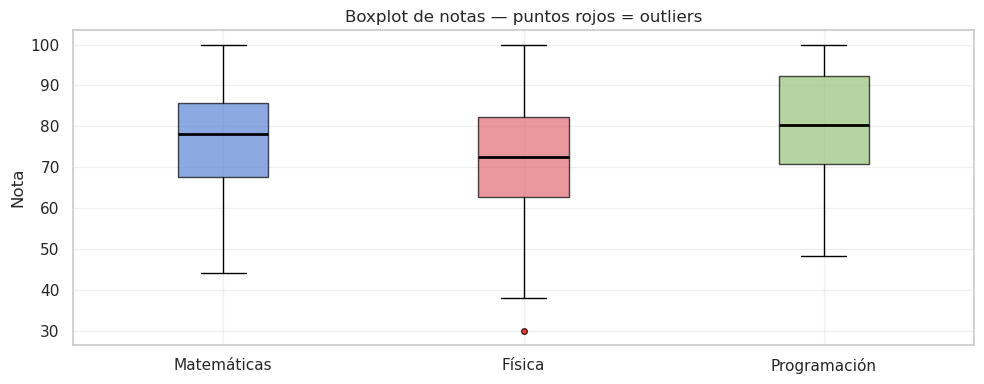

In [12]:
# Boxplot para visualizar outliers
fig, ax = plt.subplots(figsize=(10, 4))

datos_notas = [df['nota_mat'].dropna().values,
               df['nota_fis'].dropna().values,
               df['nota_prog'].dropna().values]

bp = ax.boxplot(datos_notas,
                labels=['Matemáticas', 'Física', 'Programación'],
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2},
                flierprops={'marker': 'o', 'markersize': 4,
                            'markerfacecolor': 'red', 'alpha': 0.5})

for patch, color in zip(bp['boxes'], ['#5C85D6', '#E06C75', '#98C379']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Boxplot de notas — puntos rojos = outliers')
ax.set_ylabel('Nota')
plt.tight_layout()
plt.show()

---
## 6. Análisis Bivariado

El análisis bivariado estudia la **relación entre dos variables**.
La pregunta típica: ¿cuando una sube, la otra también sube (o baja)?

### 6.1 Numérica vs. Numérica — Correlación

La **correlación de Pearson** es un número entre -1 y 1:
- **+1**: correlación perfecta positiva (cuando una sube, la otra sube proporcional)
- **0**: sin correlación lineal
- **-1**: correlación perfecta negativa

Regla empírica para interpretar:
- `|r| > 0.7`: fuerte
- `0.4 < |r| ≤ 0.7`: moderada
- `|r| ≤ 0.4`: débil

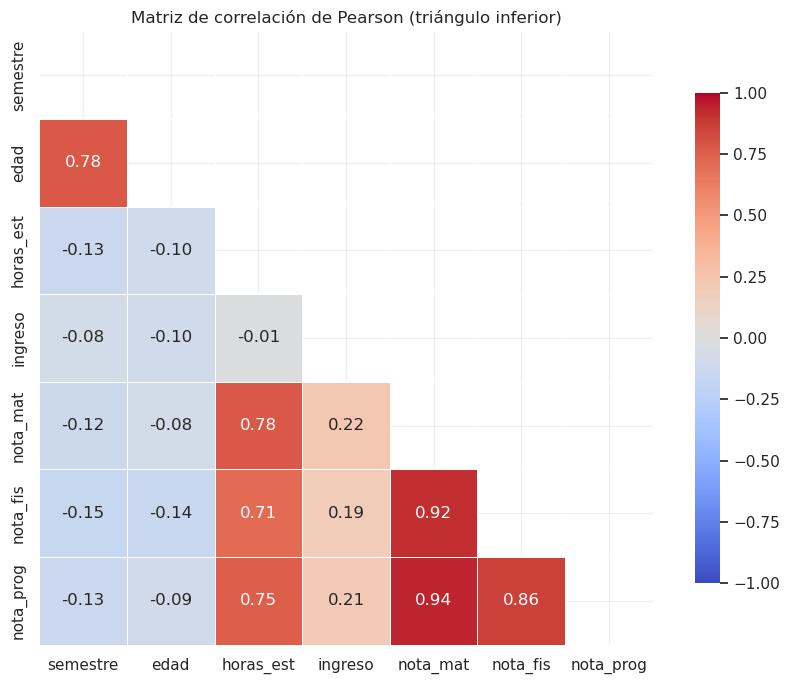

Correlación con nota_mat (ordenada por magnitud):
  nota_prog    : |r| = 0.940  → FUERTE
  nota_fis     : |r| = 0.920  → FUERTE
  horas_est    : |r| = 0.780  → FUERTE
  ingreso      : |r| = 0.220  → débil
  semestre     : |r| = 0.120  → débil
  edad         : |r| = 0.080  → débil


In [13]:
cols_corr = ['semestre', 'edad', 'horas_est', 'ingreso', 'nota_mat', 'nota_fis', 'nota_prog']
corr_mat  = df[cols_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
# Máscara para ocultar el triángulo superior (evitar información duplicada)
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de correlación de Pearson (triángulo inferior)')
plt.tight_layout()
plt.show()

# Identificar las correlaciones más fuertes con nota_mat — ciclo for
print('Correlación con nota_mat (ordenada por magnitud):')
corr_con_mat = corr_mat['nota_mat'].drop('nota_mat').abs().sort_values(ascending=False)

for variable, r in corr_con_mat.items():
    # Condicional: describir la intensidad
    if r > 0.7:
        descripcion = 'FUERTE'
    elif r > 0.4:
        descripcion = 'moderada'
    else:
        descripcion = 'débil'
    print(f'  {variable:<12} : |r| = {r:.3f}  → {descripcion}')

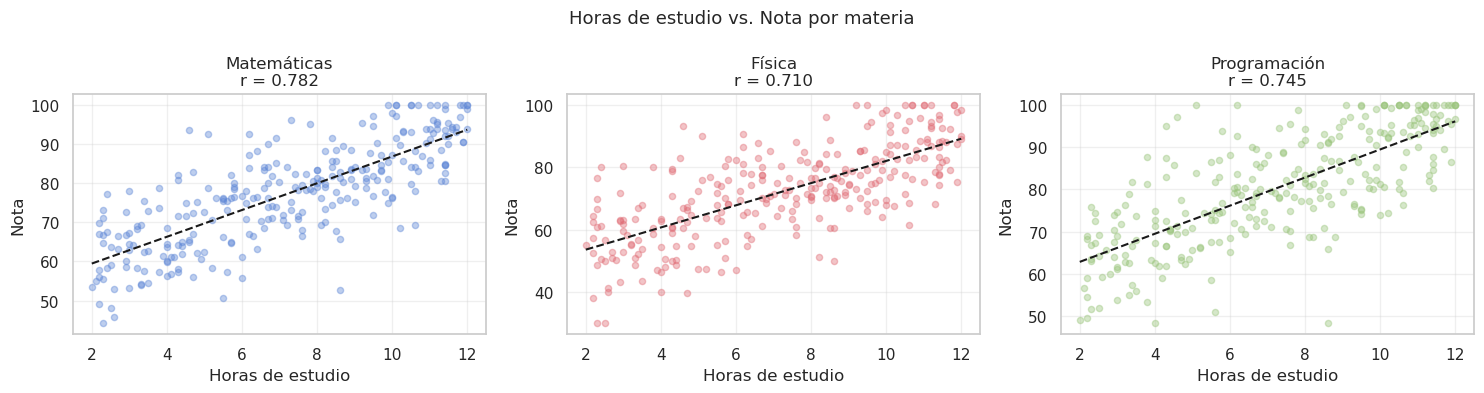

In [14]:
# Scatter plots: horas de estudio vs. cada nota — ciclo for
notas_cols = ['nota_mat', 'nota_fis', 'nota_prog']
titulos_sc = ['Matemáticas', 'Física', 'Programación']
colores_sc = ['#5C85D6', '#E06C75', '#98C379']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (col, titulo, color) in enumerate(zip(notas_cols, titulos_sc, colores_sc)):
    # Eliminar filas con NaN en alguna de las dos variables
    datos_validos = df[['horas_est', col]].dropna()
    x = datos_validos['horas_est']
    y = datos_validos[col]

    axes[i].scatter(x, y, alpha=0.4, color=color, s=20)

    # Línea de tendencia
    coefs = np.polyfit(x, y, 1)
    x_l   = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(x_l, np.poly1d(coefs)(x_l), 'k--', linewidth=1.5)

    r = np.corrcoef(x, y)[0, 1]
    axes[i].set_title(f'{titulo}\nr = {r:.3f}')
    axes[i].set_xlabel('Horas de estudio')
    axes[i].set_ylabel('Nota')

fig.suptitle('Horas de estudio vs. Nota por materia', fontsize=13)
plt.tight_layout()
plt.show()

### 6.2 Categórica vs. Numérica

Cuando una variable es categórica y la otra es numérica, la pregunta es:
**¿Las distribuciones de la variable numérica difieren entre los grupos?**

Herramientas visuales: boxplot, violinplot, barplot con IC.
Herramienta estadística: ANOVA (para comparar medias entre múltiples grupos).

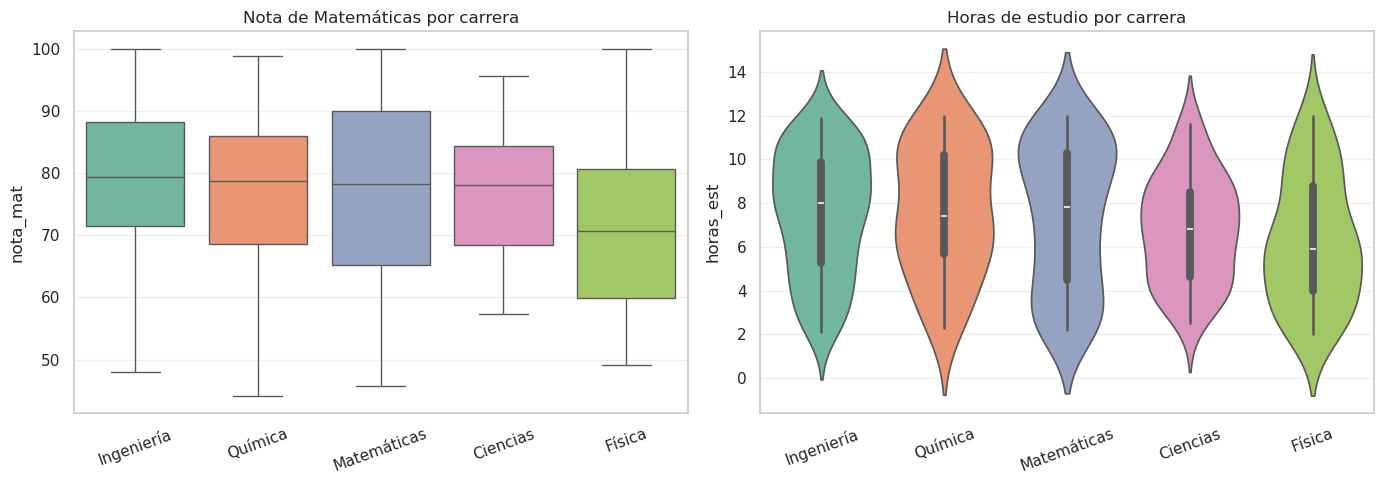

Resumen por carrera:
Carrera             N   Nota Mat   Nota Fis    Horas
----------------------------------------------------
Ingeniería        122       78.7       74.4      7.5
Química            26       77.3       70.5      7.6
Matemáticas        63       77.6       72.0      7.4
Ciencias           49       77.0       71.4      6.8
Física             40       71.4       67.7      6.3


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ordenar carreras por mediana de nota_mat (descendente)
orden = (df.groupby('carrera')['nota_mat']
           .median()
           .sort_values(ascending=False)
           .index)

# Boxplot
sns.boxplot(data=df, x='carrera', y='nota_mat',
            order=orden, palette='Set2', ax=axes[0])
axes[0].set_title('Nota de Matemáticas por carrera')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# Violinplot de horas de estudio
sns.violinplot(data=df, x='carrera', y='horas_est',
               order=orden, palette='Set2',
               inner='box', ax=axes[1])
axes[1].set_title('Horas de estudio por carrera')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Resumen numérico por carrera — ciclo for
print('Resumen por carrera:')
print(f'{"Carrera":<15} {"N":>5} {"Nota Mat":>10} {"Nota Fis":>10} {"Horas":>8}')
print('-' * 52)

for carrera in orden:
    sub = df[df['carrera'] == carrera]
    n       = len(sub)
    mat     = sub['nota_mat'].mean()
    fis     = sub['nota_fis'].mean()
    horas   = sub['horas_est'].mean()
    print(f'{carrera:<15} {n:>5} {mat:>10.1f} {fis:>10.1f} {horas:>8.1f}')

---
## 7. Análisis Multivariado

En el análisis multivariado buscamos **patrones que involucran varias variables al mismo tiempo**.

Herramientas:
- **Pairplot**: scatter de todos los pares de variables, coloreado por categoría
- **Heatmap de pivot table**: promedio de una variable en función de 2 categorías

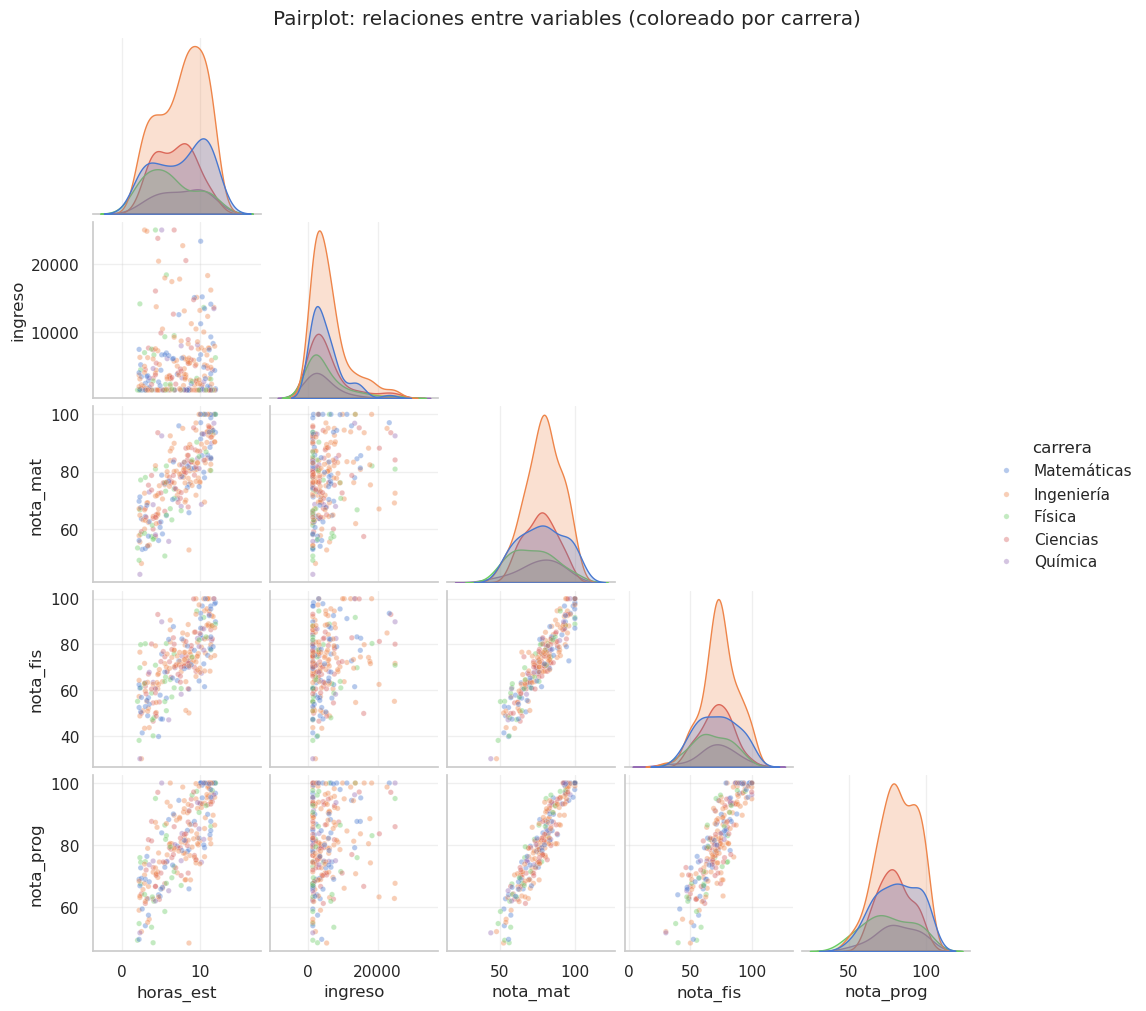

In [16]:
# Pairplot: solo las variables más relevantes para no sobrecargar
cols_pair = ['horas_est', 'ingreso', 'nota_mat', 'nota_fis', 'nota_prog']
df_pair   = df[cols_pair + ['carrera']].dropna()

g = sns.pairplot(df_pair, hue='carrera', corner=True,
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde', height=2.0)
g.fig.suptitle('Pairplot: relaciones entre variables (coloreado por carrera)', y=1.01)
plt.show()

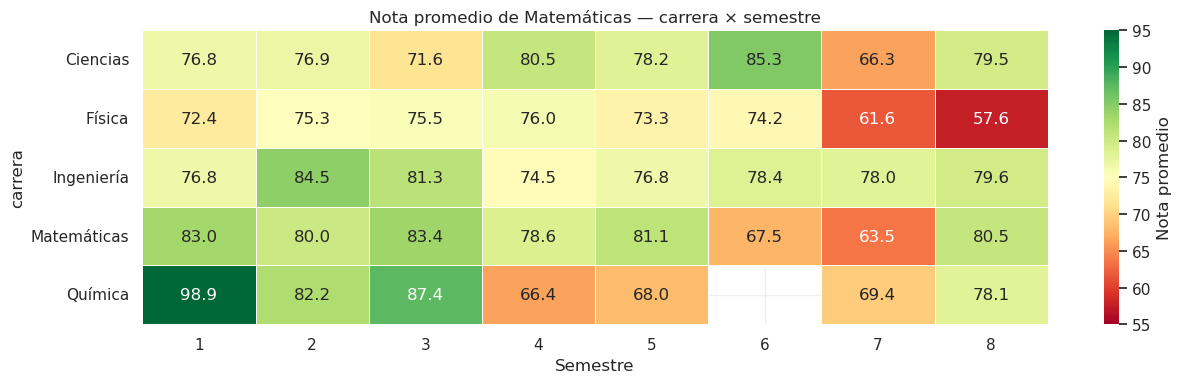

In [17]:
# Heatmap de tabla pivote: promedio de nota_mat por carrera × semestre
pivot = df.pivot_table(
    values='nota_mat',
    index='carrera',
    columns='semestre',
    aggfunc='mean'
).round(1)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Nota promedio'},
            ax=ax, vmin=55, vmax=95)
ax.set_title('Nota promedio de Matemáticas — carrera × semestre')
ax.set_xlabel('Semestre')
plt.tight_layout()
plt.show()

---
## 8. Ingeniería de Features

La **ingeniería de features** es crear nuevas variables a partir de las existentes.
El objetivo es representar la información de una forma más útil para el análisis o modelado.

Ejemplos comunes:
- **Promedios**: combinar varias notas en una sola variable resumen
- **Categorización** (`pd.cut`): convertir un número en una categoría con significado
- **Ratios**: nota / horas de estudio → eficiencia de aprendizaje
- **Indicadores binarios**: ¿aprobó o no aprobó?

Usamos `pd.cut` para categorizar valores numéricos en rangos:

In [18]:
df2 = df.copy()

# 1. Promedio general (media de las tres notas por fila)
df2['promedio'] = df2[['nota_mat', 'nota_fis', 'nota_prog']].mean(axis=1).round(1)

# 2. Estado académico — pd.cut divide en bins y les da etiquetas
df2['estado'] = pd.cut(
    df2['promedio'],
    bins=[0, 59.9, 69.9, 79.9, 100],
    labels=['Reprobado', 'Suficiente', 'Bueno', 'Excelente']
)

# 3. Nivel de ingresos — pd.qcut divide en cuartiles (grupos de igual tamaño)
df2['nivel_ingreso'] = pd.qcut(
    df2['ingreso'], q=3,
    labels=['Bajo', 'Medio', 'Alto']
)

# 4. Eficiencia: cuántos puntos de promedio por hora de estudio
df2['eficiencia'] = (df2['promedio'] / df2['horas_est']).round(2)

# 5. Indicador binario: aprobado (promedio >= 60)
df2['aprobado'] = df2['promedio'] >= 60

print('Nuevas features creadas:')
print(df2[['promedio', 'estado', 'nivel_ingreso', 'eficiencia', 'aprobado']].head(8))

print('\nDistribución de estados académicos:')
print(df2['estado'].value_counts())

tasa_aprobacion = df2['aprobado'].mean() * 100
print(f'\nTasa de aprobación: {tasa_aprobacion:.1f}%')

Nuevas features creadas:
   promedio     estado nivel_ingreso  eficiencia  aprobado
0      75.6      Bueno          Bajo        8.79      True
1      51.3  Reprobado          Bajo       14.66     False
2      79.0      Bueno         Medio       17.56      True
3      70.8      Bueno          Alto       30.78      True
4      99.4  Excelente          Bajo        8.28      True
5      71.0      Bueno         Medio        7.47      True
6      76.6      Bueno          Bajo       10.49      True
7      90.4  Excelente          Alto        8.37      True

Distribución de estados académicos:
estado
Excelente     127
Bueno          86
Suficiente     52
Reprobado      35
Name: count, dtype: int64

Tasa de aprobación: 88.3%


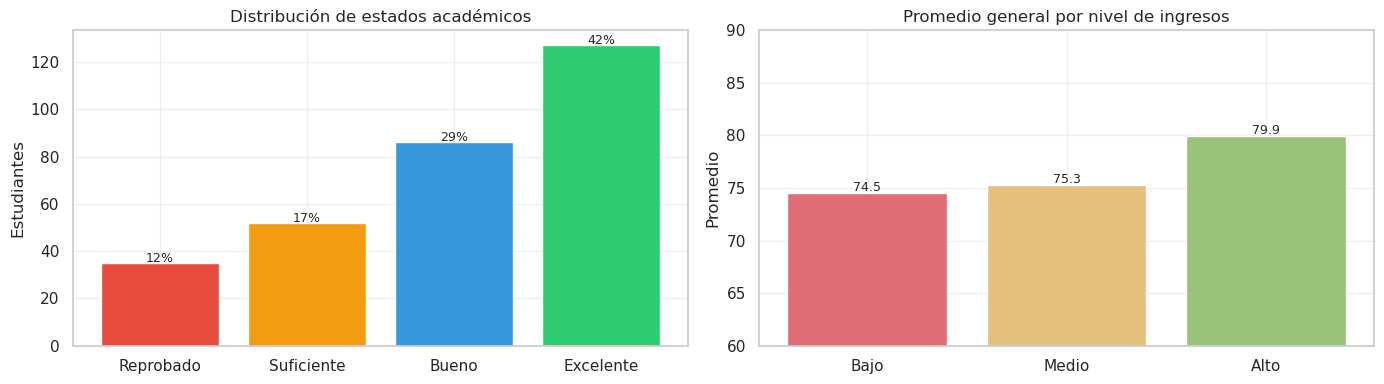

In [19]:
# Visualizar las nuevas features
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel izquierdo: distribución de estados académicos con color por estado
palette_estado = {
    'Reprobado':  '#e74c3c',
    'Suficiente': '#f39c12',
    'Bueno':      '#3498db',
    'Excelente':  '#2ecc71',
}
conteo_estado = df2['estado'].value_counts().sort_index()

for estado, cantidad in conteo_estado.items():
    bar = axes[0].bar(estado, cantidad, color=palette_estado.get(str(estado), 'gray'))
    pct = cantidad / len(df2) * 100
    axes[0].text(estado, cantidad + 0.5, f'{pct:.0f}%', ha='center', fontsize=9)

axes[0].set_title('Distribución de estados académicos')
axes[0].set_ylabel('Estudiantes')

# Panel derecho: promedio por nivel de ingreso
prom_por_ingreso = df2.groupby('nivel_ingreso', observed=True)['promedio'].mean()

colores_ingreso = ['#E06C75', '#E5C07B', '#98C379']
bars2 = axes[1].bar(prom_por_ingreso.index, prom_por_ingreso.values,
                    color=colores_ingreso)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.2,
                 f'{bar.get_height():.1f}',
                 ha='center', fontsize=9)

axes[1].set_title('Promedio general por nivel de ingresos')
axes[1].set_ylabel('Promedio')
axes[1].set_ylim(60, 90)

plt.tight_layout()
plt.show()

---
## 9. Imputación de Valores Faltantes

Ahora que entendemos el dataset, podemos decidir **cómo llenar los NaN**.

Estrategias:
- **Media**: sensible a outliers, buena para distribuciones simétricas
- **Mediana**: robusta a outliers, mejor para distribuciones sesgadas
- **Moda**: para variables categóricas
- **Mediana por grupo**: más precisa cuando los grupos tienen niveles diferentes

Para las notas, imputamos con la **mediana por carrera** porque cada carrera
tiene diferente nivel de exigencia.
Para la ciudad, usamos la **moda global**.

In [20]:
df_clean = df2.copy()

# Imputar notas con mediana por carrera
cols_notas = ['nota_mat', 'nota_fis', 'nota_prog']

for col in cols_notas:
    antes = df_clean[col].isnull().sum()

    # transform('median') aplica la mediana de cada grupo a cada fila del grupo
    mediana_por_carrera = df_clean.groupby('carrera')[col].transform('median')
    df_clean[col] = df_clean[col].fillna(mediana_por_carrera)

    despues = df_clean[col].isnull().sum()
    print(f'{col:<12}: {antes} NaN → {despues} NaN (imputados con mediana por carrera)')

# Imputar ciudad con la moda global
moda_ciudad = df_clean['ciudad'].mode()[0]
n_ciudad_nan = df_clean['ciudad'].isnull().sum()
df_clean['ciudad'] = df_clean['ciudad'].fillna(moda_ciudad)
print(f'ciudad    : {n_ciudad_nan} NaN → 0 NaN (imputados con moda = "{moda_ciudad}")')

# Recalcular promedio después de imputación
df_clean['promedio'] = df_clean[['nota_mat', 'nota_fis', 'nota_prog']].mean(axis=1).round(1)

total_nulos_restantes = df_clean[cols_notas + ['ciudad']].isnull().sum().sum()
print(f'\nNulos restantes en columnas tratadas: {total_nulos_restantes}')

nota_mat    : 18 NaN → 0 NaN (imputados con mediana por carrera)
nota_fis    : 18 NaN → 0 NaN (imputados con mediana por carrera)
nota_prog   : 18 NaN → 0 NaN (imputados con mediana por carrera)
ciudad    : 10 NaN → 0 NaN (imputados con moda = "Guatemala")

Nulos restantes en columnas tratadas: 0


---
## 10. Resumen Final del EDA

Al final de un EDA es buena práctica **documentar los hallazgos** antes de pasar al modelado.
Esto ayuda a comunicar resultados y a tomar decisiones informadas sobre el modelo.

In [21]:
# Generar resumen automático del EDA con un ciclo for
hallazgos = [
    ('Dataset',         f'{len(df_clean)} registros × {df_clean.shape[1]} variables'),
    ('Duplicados',      '3 filas eliminadas'),
    ('Nulos notas',     '~18 imputados con mediana por carrera'),
    ('Nulos ciudad',    '10 imputados con moda global'),
    ('Carrera +común',  df_clean['carrera'].mode()[0]),
    ('Ciudad +común',   df_clean['ciudad'].mode()[0]),
    ('Horas est. prom.', f'{df_clean["horas_est"].mean():.1f} h/día'),
    ('Promedio general', f'{df_clean["promedio"].mean():.1f} / 100'),
    ('Tasa aprobación',  f'{(df_clean["promedio"] >= 60).mean()*100:.1f}%'),
]

correlaciones = [
    ('horas_est ↔ nota_mat', df_clean['horas_est'].corr(df_clean['nota_mat'])),
    ('ingreso ↔ nota_mat',   df_clean['ingreso'].corr(df_clean['nota_mat'])),
    ('nota_mat ↔ nota_fis',  df_clean['nota_mat'].corr(df_clean['nota_fis'])),
    ('nota_mat ↔ nota_prog', df_clean['nota_mat'].corr(df_clean['nota_prog'])),
]

print('=' * 55)
print('         RESUMEN FINAL DEL EDA')
print('=' * 55)

for etiqueta, valor in hallazgos:
    print(f'  {etiqueta:<22}: {valor}')

print()
print('─── Correlaciones con nota_mat ───')
for par, r in correlaciones:
    # Condicional: interpretar la correlación
    if abs(r) > 0.7:
        nivel = 'fuerte'
    elif abs(r) > 0.4:
        nivel = 'moderada'
    else:
        nivel = 'débil'
    print(f'  {par:<28}: r = {r:+.3f}  ({nivel})')

print()
print('─── Próximos pasos sugeridos ───')
pasos = [
    'Regresión lineal para predecir promedio a partir de horas_est e ingreso',
    'Clasificación (logística) para predecir aprobado/reprobado',
    'Clustering para agrupar estudiantes por perfil académico',
    'Comparar medias entre carreras con ANOVA o test de Kruskal-Wallis',
]
for paso in pasos:
    print(f'  → {paso}')

         RESUMEN FINAL DEL EDA
  Dataset               : 300 registros × 15 variables
  Duplicados            : 3 filas eliminadas
  Nulos notas           : ~18 imputados con mediana por carrera
  Nulos ciudad          : 10 imputados con moda global
  Carrera +común        : Ingeniería
  Ciudad +común         : Guatemala
  Horas est. prom.      : 7.2 h/día
  Promedio general      : 76.5 / 100
  Tasa aprobación       : 89.7%

─── Correlaciones con nota_mat ───
  horas_est ↔ nota_mat        : r = +0.763  (fuerte)
  ingreso ↔ nota_mat          : r = +0.215  (débil)
  nota_mat ↔ nota_fis         : r = +0.865  (fuerte)
  nota_mat ↔ nota_prog        : r = +0.870  (fuerte)

─── Próximos pasos sugeridos ───
  → Regresión lineal para predecir promedio a partir de horas_est e ingreso
  → Clasificación (logística) para predecir aprobado/reprobado
  → Clustering para agrupar estudiantes por perfil académico
  → Comparar medias entre carreras con ANOVA o test de Kruskal-Wallis


---
## Ejercicio 1 — EDA Básico de un Nuevo Dataset

### Enunciado

Se te proporciona el siguiente dataset de **ventas de una tienda** durante 12 meses y 5 productos.
Realiza un EDA básico que incluya:

1. Verifica si hay valores nulos y muéstralos con un ciclo `for`
2. Calcula el total de ventas por producto (suma de los 12 meses)
3. Calcula el promedio mensual por producto
4. Crea una gráfica de líneas con las ventas mensuales de cada producto (usando `for`)
5. Crea una barra del total de ventas por producto, con color **verde** si el total > 1500,
   **amarillo** si entre 1000 y 1500, y **rojo** si < 1000
6. Imprime cuál fue el **mejor mes** de cada producto

**Datos:**
```python
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ventas = pd.DataFrame({
    'Laptop':    [120, 135, 110, None, 145, 155, 160, 150, 130, 140, 170, 180],
    'Teléfono':  [200, 185, 210, 220, 190, 175, 195, 205, 215, 230, 250, 270],
    'Tablet':    [80,  75,  90,  85,  70,  None, 95, 88,  92,  78,  85,  90],
    'Audífonos': [150, 160, 145, 155, 165, 170, 158, 162, 148, 155, 180, 195],
    'Cámara':    [45,  50,  40,  None, 55,  60,  48,  52,  44,  None, 65,  70],
}, index=meses)
```

In [22]:
# === Intenta tu solución aquí ===
meses_ej = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ventas = pd.DataFrame({
    'Laptop':    [120, 135, 110, None, 145, 155, 160, 150, 130, 140, 170, 180],
    'Teléfono':  [200, 185, 210, 220, 190, 175, 195, 205, 215, 230, 250, 270],
    'Tablet':    [80,  75,  90,  85,  70, None,  95,  88,  92,  78,  85,  90],
    'Audífonos': [150, 160, 145, 155, 165, 170, 158, 162, 148, 155, 180, 195],
    'Cámara':    [45,  50,  40, None,  55,  60,  48,  52,  44, None,  65,  70],
}, index=meses_ej)


=== Paso 1: Valores nulos por producto ===
  Laptop      : 1 nulo(s) → meses: ['Abr']
  Teléfono    : sin nulos ✓
  Tablet      : 1 nulo(s) → meses: ['Jun']
  Audífonos   : sin nulos ✓
  Cámara      : 2 nulo(s) → meses: ['Abr', 'Oct']

=== Pasos 2 y 3: Totales y promedios ===
Producto        Total   Promedio
---------------------------------
Laptop           1740      145.0
Teléfono         2545      212.1
Tablet           1013       84.4
Audífonos        1943      161.9
Cámara            631       52.6


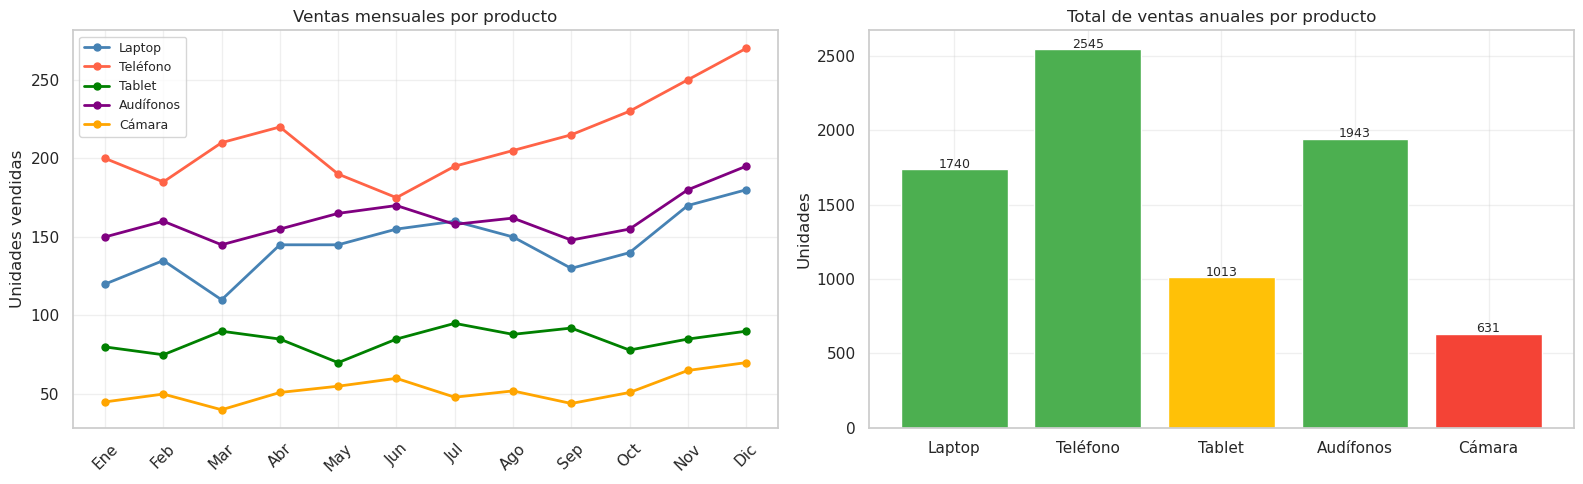


=== Paso 6: Mejor mes por producto ===
  Laptop      : mejor mes = Dic (180 unidades)
  Teléfono    : mejor mes = Dic (270 unidades)
  Tablet      : mejor mes = Jul (95 unidades)
  Audífonos   : mejor mes = Dic (195 unidades)
  Cámara      : mejor mes = Dic (70 unidades)


In [23]:
# ═══════════════════════════════════════════════════════
#  SOLUCIÓN — Ejercicio 1: EDA de Ventas
# ═══════════════════════════════════════════════════════
meses_ej = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ventas = pd.DataFrame({
    'Laptop':    [120, 135, 110, None, 145, 155, 160, 150, 130, 140, 170, 180],
    'Teléfono':  [200, 185, 210, 220, 190, 175, 195, 205, 215, 230, 250, 270],
    'Tablet':    [80,  75,  90,  85,  70, None,  95,  88,  92,  78,  85,  90],
    'Audífonos': [150, 160, 145, 155, 165, 170, 158, 162, 148, 155, 180, 195],
    'Cámara':    [45,  50,  40, None,  55,  60,  48,  52,  44, None,  65,  70],
}, index=meses_ej)

# ─── 1. Valores nulos por producto ───
print('=== Paso 1: Valores nulos por producto ===')
for producto in ventas.columns:
    n_nulos = ventas[producto].isnull().sum()
    if n_nulos > 0:
        meses_faltantes = [m for m, v in zip(meses_ej, ventas[producto]) if pd.isna(v)]
        print(f'  {producto:<12}: {n_nulos} nulo(s) → meses: {meses_faltantes}')
    else:
        print(f'  {producto:<12}: sin nulos ✓')

# Imputar nulos con la mediana de cada producto antes de continuar
ventas_limpias = ventas.copy()
for col in ventas_limpias.columns:
    mediana_col = ventas_limpias[col].median()
    ventas_limpias[col] = ventas_limpias[col].fillna(mediana_col)

# ─── 2 & 3. Total y promedio por producto ───
print('\n=== Pasos 2 y 3: Totales y promedios ===')
print(f'{"Producto":<12} {"Total":>8} {"Promedio":>10}')
print('-' * 33)
for producto in ventas_limpias.columns:
    total_p = ventas_limpias[producto].sum()
    prom_p  = ventas_limpias[producto].mean()
    print(f'{producto:<12} {total_p:>8.0f} {prom_p:>10.1f}')

# ─── 4. Gráfica de líneas ───
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colores_prod = ['steelblue', 'tomato', 'green', 'purple', 'orange']
x_plot = range(12)

for (producto, serie), color in zip(ventas_limpias.items(), colores_prod):
    axes[0].plot(x_plot, serie.values,
                 marker='o', linewidth=2, markersize=5,
                 label=producto, color=color)

axes[0].set_xticks(x_plot)
axes[0].set_xticklabels(meses_ej, rotation=45)
axes[0].set_title('Ventas mensuales por producto')
axes[0].set_ylabel('Unidades vendidas')
axes[0].legend(fontsize=9)

# ─── 5. Barras con color condicional ───
totales_productos = {}
colores_bar       = []

for producto in ventas_limpias.columns:
    total_p = ventas_limpias[producto].sum()
    totales_productos[producto] = total_p

    if total_p > 1500:
        colores_bar.append('#4CAF50')    # verde
    elif total_p >= 1000:
        colores_bar.append('#FFC107')    # amarillo
    else:
        colores_bar.append('#F44336')    # rojo

bars = axes[1].bar(totales_productos.keys(), totales_productos.values(),
                   color=colores_bar, edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 10,
                 f'{bar.get_height():.0f}',
                 ha='center', fontsize=9)

axes[1].set_title('Total de ventas anuales por producto')
axes[1].set_ylabel('Unidades')

plt.tight_layout()
plt.show()

# ─── 6. Mejor mes por producto ───
print('\n=== Paso 6: Mejor mes por producto ===')
for producto in ventas_limpias.columns:
    idx_max      = ventas_limpias[producto].idxmax()   # índice = nombre del mes
    valor_max    = ventas_limpias[producto].max()
    print(f'  {producto:<12}: mejor mes = {idx_max} ({valor_max:.0f} unidades)')

---
## Ejercicio 2 — EDA Comparativo entre Grupos

### Enunciado

Tienes un dataset de pacientes con mediciones de presión arterial sistólica (en mmHg).
El dataset tiene 3 grupos: **Control**, **Tratamiento A** y **Tratamiento B**.

```python
# Los datos se generan en la siguiente celda
```

Realiza el siguiente análisis:

1. **Estadísticos por grupo**: usando un ciclo `for`, calcula e imprime la media, mediana y std
   de cada grupo
2. **Visualización**: crea un panel de 3 gráficas:
   - Histograma de los 3 grupos superpuestos
   - Boxplot comparando los 3 grupos
   - Barras del promedio por grupo con color condicional
     (verde si ≤ 130, amarillo si 130–140, rojo si > 140)
3. **Detección de outliers**: usa el método IQR para cada grupo con un ciclo `for`
4. **Conclusión**: imprime si hay diferencia significativa (diferencia entre grupos > 10 mmHg)

**Nota:** La presión normal es ≤ 120 mmHg; prehipertensión 120-139; hipertensión ≥ 140.

In [24]:
# Datos del ejercicio — ejecuta esta celda primero
rng2 = np.random.default_rng(99)
n_pac = 80

presion = pd.DataFrame({
    'Control':       rng2.normal(145, 15, n_pac).clip(100, 200).round(1),
    'Tratamiento A': rng2.normal(130, 12, n_pac).clip(100, 180).round(1),
    'Tratamiento B': rng2.normal(118, 10, n_pac).clip(90,  160).round(1),
})

print('Dataset generado:', presion.shape)
presion.head()

Dataset generado: (80, 3)


,Control,Tratamiento A,Tratamiento B
0,146.2,129.0,125.4
1,138.0,129.1,96.5
2,145.8,132.3,116.3
3,155.3,121.1,101.6
4,118.6,130.2,112.9


In [25]:
# === Intenta tu solución aquí ===


=== Estadísticos por grupo ===
Grupo              Media   Mediana      Std
---------------------------------------------
Control            146.9     147.4     13.5
Tratamiento A      129.4     129.9     12.1
Tratamiento B      118.4     120.2      9.9


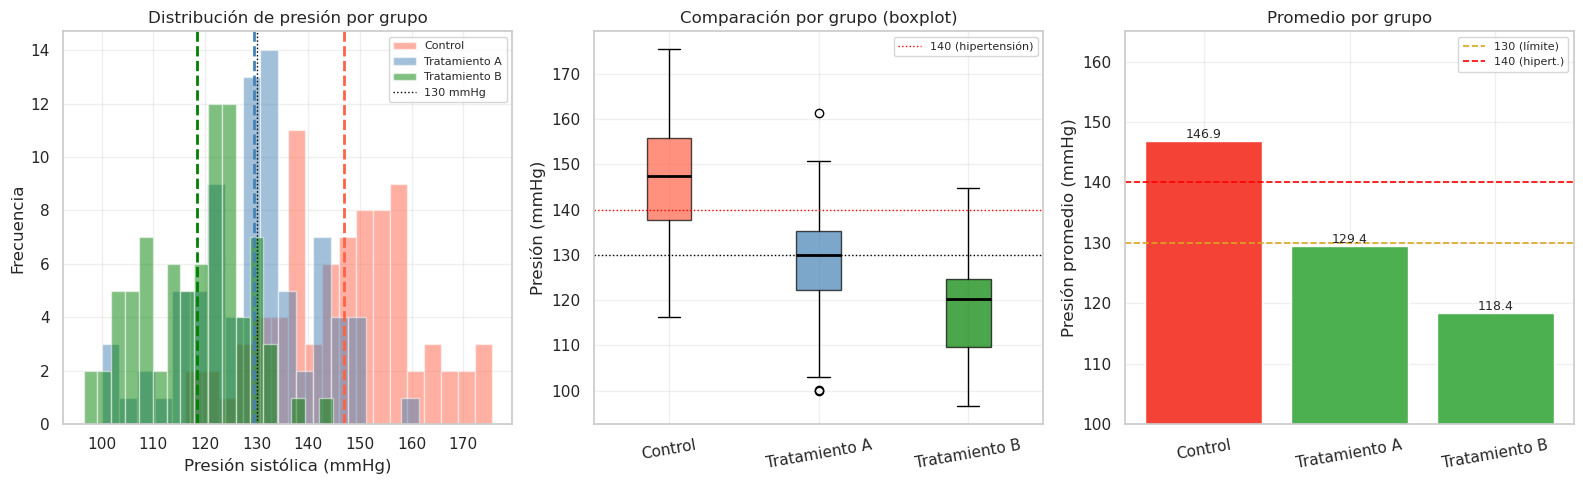


=== Outliers por grupo (método IQR) ===
  Control        : 0 outliers (0.0%)
  Tratamiento A  : 3 outliers (3.8%)
  Tratamiento B  : 0 outliers (0.0%)

=== Conclusión ===
  Diferencia máxima entre grupos: 28.6 mmHg → HAY diferencia clínicamente relevante
  Grupo con menor presión promedio: Tratamiento B (118.4 mmHg)


In [26]:
# ═══════════════════════════════════════════════════════
#  SOLUCIÓN — Ejercicio 2: EDA Comparativo
# ═══════════════════════════════════════════════════════

# ─── 1. Estadísticos por grupo ───
print('=== Estadísticos por grupo ===')
print(f'{"Grupo":<15} {"Media":>8} {"Mediana":>9} {"Std":>8}')
print('-' * 45)

medias_grupos = {}
for grupo in presion.columns:
    datos_g = presion[grupo].dropna()
    media   = datos_g.mean()
    mediana = datos_g.median()
    std     = datos_g.std()
    medias_grupos[grupo] = media
    print(f'{grupo:<15} {media:>8.1f} {mediana:>9.1f} {std:>8.1f}')

# ─── 2. Visualización ───
colores_grupos = {'Control': 'tomato', 'Tratamiento A': 'steelblue', 'Tratamiento B': 'green'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma superpuesto
for grupo, color in colores_grupos.items():
    axes[0].hist(presion[grupo], bins=18, alpha=0.5,
                 color=color, label=grupo, edgecolor='white')
    axes[0].axvline(presion[grupo].mean(), color=color,
                    linestyle='--', linewidth=2)

axes[0].axvline(130, color='black', linewidth=1, linestyle=':', label='130 mmHg')
axes[0].set_title('Distribución de presión por grupo')
axes[0].set_xlabel('Presión sistólica (mmHg)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=8)

# Boxplot
datos_lista_bp = [presion[g].dropna().values for g in presion.columns]
bp = axes[1].boxplot(datos_lista_bp, labels=list(presion.columns),
                     patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colores_grupos.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].axhline(130, color='black', linestyle=':', linewidth=1)
axes[1].axhline(140, color='red',   linestyle=':', linewidth=1, label='140 (hipertensión)')
axes[1].set_title('Comparación por grupo (boxplot)')
axes[1].set_ylabel('Presión (mmHg)')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=10)

# Barras con color condicional
colores_bar_ej2 = []
for grupo, media in medias_grupos.items():
    if media <= 130:
        colores_bar_ej2.append('#4CAF50')    # verde: controlada
    elif media <= 140:
        colores_bar_ej2.append('#FFC107')    # amarillo: prehipertensión
    else:
        colores_bar_ej2.append('#F44336')    # rojo: hipertensión

bars = axes[2].bar(medias_grupos.keys(), medias_grupos.values(),
                   color=colores_bar_ej2, edgecolor='white')
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}',
                 ha='center', fontsize=9)

axes[2].axhline(130, color='goldenrod', linestyle='--', linewidth=1.2, label='130 (límite)')
axes[2].axhline(140, color='red',       linestyle='--', linewidth=1.2, label='140 (hipert.)')
axes[2].set_title('Promedio por grupo')
axes[2].set_ylabel('Presión promedio (mmHg)')
axes[2].set_ylim(100, 165)
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

# ─── 3. Detección de outliers por grupo ───
print('\n=== Outliers por grupo (método IQR) ===')
for grupo in presion.columns:
    datos_g = presion[grupo].dropna()
    Q1 = datos_g.quantile(0.25)
    Q3 = datos_g.quantile(0.75)
    IQR = Q3 - Q1
    outliers = datos_g[(datos_g < Q1 - 1.5 * IQR) | (datos_g > Q3 + 1.5 * IQR)]
    print(f'  {grupo:<15}: {len(outliers)} outliers ({len(outliers)/len(datos_g)*100:.1f}%)')

# ─── 4. Conclusión ───
print('\n=== Conclusión ===')
lista_medias = list(medias_grupos.values())
diferencia_max = max(lista_medias) - min(lista_medias)

if diferencia_max > 10:
    print(f'  Diferencia máxima entre grupos: {diferencia_max:.1f} mmHg → HAY diferencia clínicamente relevante')
else:
    print(f'  Diferencia máxima entre grupos: {diferencia_max:.1f} mmHg → sin diferencia relevante')

mejor_grupo = min(medias_grupos, key=medias_grupos.get)
print(f'  Grupo con menor presión promedio: {mejor_grupo} ({medias_grupos[mejor_grupo]:.1f} mmHg)')